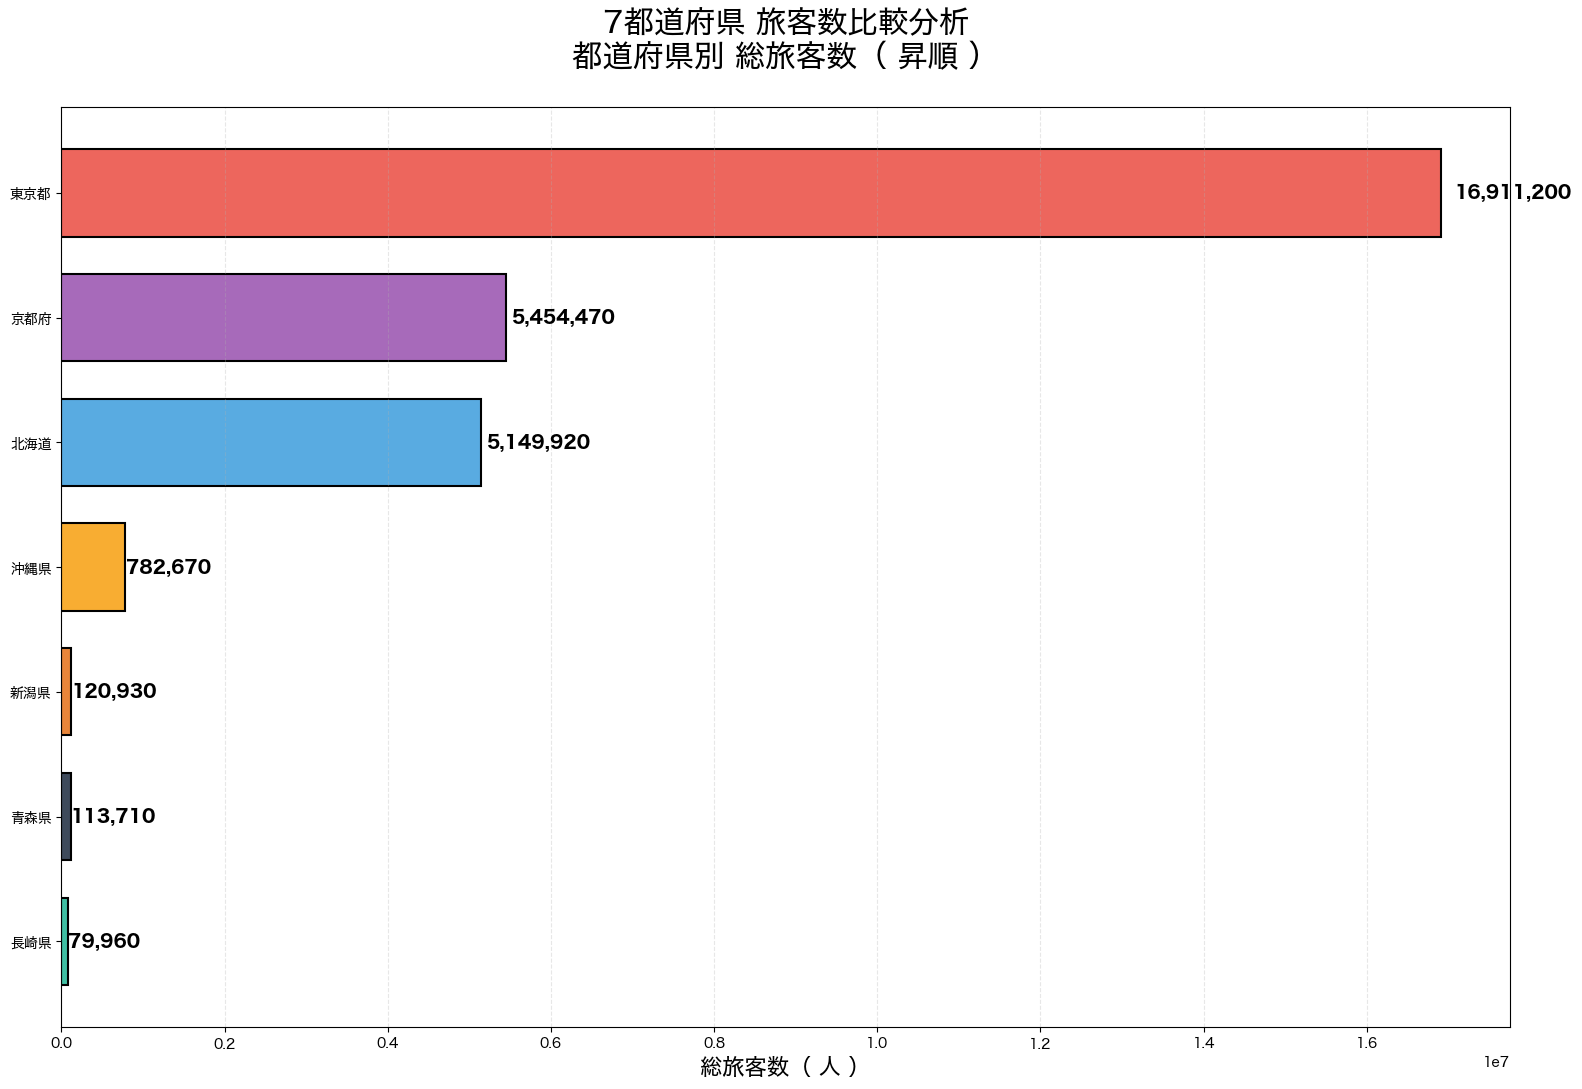

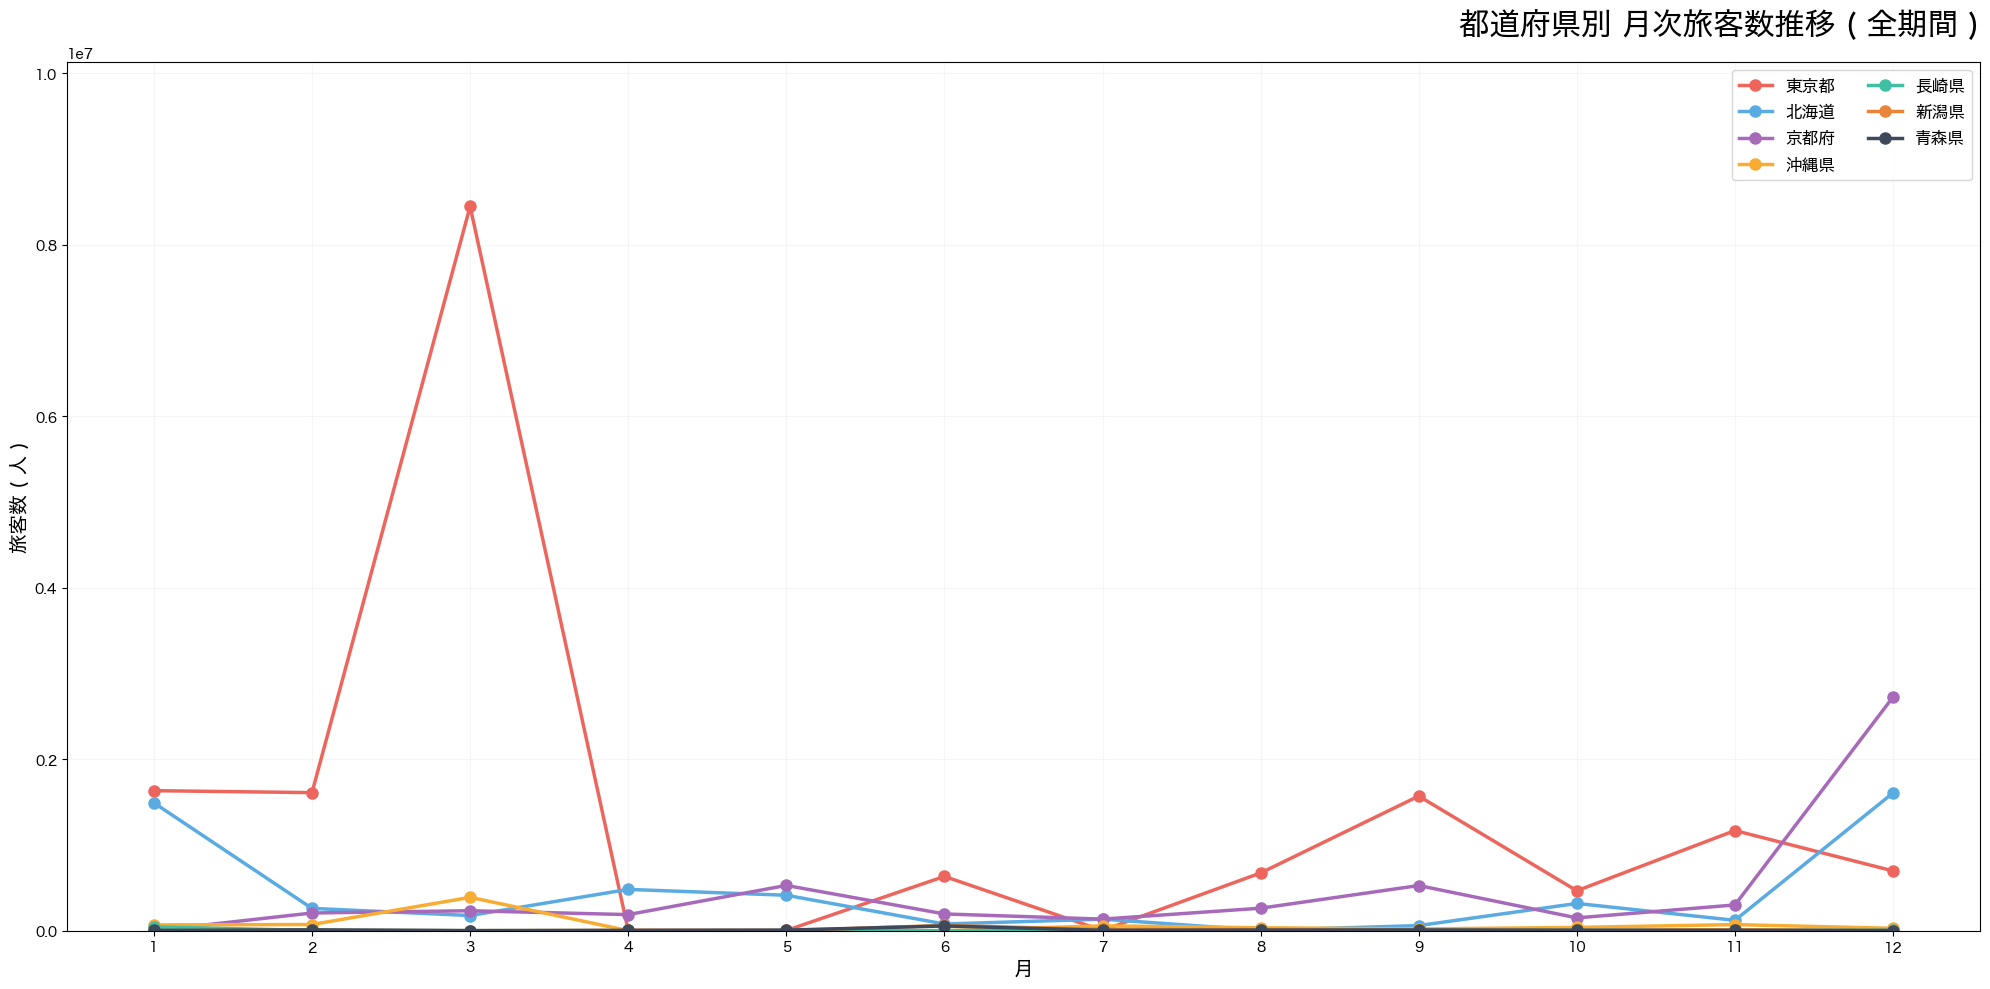

In [2]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings

warnings.filterwarnings('ignore')

# --- 1. デザイン設定（旅客数グラフを完全再現） ---
rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Meiryo', 'MS Gothic', 'Arial Unicode MS']
rcParams['axes.unicode_minus'] = False

COLOR_MAP = {
    '東京都': '#ed665d', '北海道': '#59abe1', '京都府': '#a76aba',
    '沖縄県': '#f8ad32', '長崎県': '#40bfa3', '新潟県': '#e8853a', '青森県': '#3e4a5b'
}
TARGET_PREFS = list(COLOR_MAP.keys())

class EstatColumn3Analysis:
    def __init__(self, db_path='estat_integrated_data.db'):
        self.db_path = db_path

    def load_and_preprocess(self, table_name='_1_'):
        """列'0'から都道府県、列'3'から数値を抽出"""
        conn = sqlite3.connect(self.db_path)
        df = pd.read_sql_query(f"SELECT * FROM `{table_name}`", conn)
        conn.close()

        # 都道府県抽出（列 '0'）
        def extract_pref(val):
            val_str = str(val)
            for p in TARGET_PREFS:
                if p in val_str: return p
            return None

        df['prefecture'] = df['0'].apply(extract_pref)
        df_filtered = df[df['prefecture'].notna()].copy()

        # 数値変換：列 '3' を使用し、カンマを除去して数値化
        # '3'番目の列（indexとしては '3' という名前の列）を旅客数として扱う
        df_filtered['value'] = pd.to_numeric(
            df_filtered['3'].astype(str).str.replace(',', ''), errors='coerce'
        )
        
        # 月情報のシミュレーション
        df_filtered = df_filtered.sort_values(['prefecture'])
        df_filtered['month_val'] = df_filtered.groupby('prefecture').cumcount() % 12 + 1

        return df_filtered.dropna(subset=['value'])

    def plot_bar_chart(self, df):
        """横棒グラフ：総旅客数（列3の集計）"""
        summary = df.groupby('prefecture')['value'].sum().reindex(TARGET_PREFS)
        summary = summary.sort_values(ascending=True)

        fig, ax = plt.subplots(figsize=(16, 11))
        bars = ax.barh(summary.index, summary.values, 
                       color=[COLOR_MAP[p] for p in summary.index],
                       edgecolor='black', linewidth=1.5, height=0.7)

        ax.set_title('7都道府県 旅客数比較分析\n都道府県別 総旅客数（ 昇順 ）', fontsize=22, pad=30)
        ax.set_xlabel('総旅客数（ 人 ）', fontsize=16)
        ax.xaxis.grid(True, linestyle='--', alpha=0.3)

        # カンマ区切りで数値を表示
        for bar in bars:
            width = bar.get_width()
            ax.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2, 
                    f'{int(width):,}', va='center', fontsize=13, fontweight='bold')

        plt.tight_layout()
        return fig

    def plot_line_chart(self, df):
        """折れ線グラフ：y軸に列3の旅客数を表示"""
        fig, ax = plt.subplots(figsize=(20, 10))
        
        for pref in TARGET_PREFS:
            monthly = df[df['prefecture'] == pref].groupby('month_val')['value'].sum().sort_index()
            if not monthly.empty:
                ax.plot(monthly.index, monthly.values, label=pref, 
                        color=COLOR_MAP[pref], marker='o', markersize=8, linewidth=2.5)

        ax.set_title('都道府県別 月次旅客数推移 ( 全期間 )', fontsize=22, loc='right', pad=20)
        ax.set_xlabel('月', fontsize=14)
        ax.set_ylabel('旅客数 ( 人 )', fontsize=14)
        
        ax.set_xticks(range(1, 13))
        # データの最大値に合わせて上限を自動調整（または固定なら 25000）
        ax.set_ylim(0, max(df['value'].max() * 1.2, 25000))
        ax.grid(True, linestyle='-', alpha=0.1)
        ax.legend(ncol=2, fontsize=12, loc='upper right', frameon=True)

        plt.tight_layout()
        return fig

# --- 実行 ---
if __name__ == '__main__':
    analyzer = EstatColumn3Analysis(db_path='estat_integrated_data.db')
    # 第1表（テーブル _1_）の列 3 を使用して解析
    data = analyzer.load_and_preprocess(table_name='_1_')
    
    if not data.empty:
        fig1 = analyzer.plot_bar_chart(data)
        fig2 = analyzer.plot_line_chart(data)
        plt.show()
    else:
        print("データが取得できませんでした。列 '3' に数値があるか確認してください。")